# Eksperimen Sertifikasi Machine Learning (MSML)

**Nama**: Aidms

Notebook ini mengikuti Template Eksperimen MSML untuk melakukan eksplorasi data dan preprocessing pada dataset Diabetes.

---
## 1. Perkenalan Dataset

Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle, UCI ML Repository, Open Data*) atau data primer yang Anda kumpulkan sendiri.

### Dataset yang Digunakan

- **Nama Dataset**: Diabetes Dataset (Scikit-learn)
- **Sumber**: Scikit-learn built-in dataset / [UCI ML Repository](https://archive.ics.uci.edu/)
- **Jumlah Data**: 442 sampel
- **Jumlah Fitur**: 10 fitur numerik + 1 target
- **Tipe Task**: Regresi (Prediksi progression penyakit diabetes)

### Deskripsi Fitur

| No | Fitur | Deskripsi |
|:---:|:------|:----------|
| 1 | `age` | Usia pasien |
| 2 | `sex` | Jenis kelamin pasien |
| 3 | `bmi` | Body Mass Index (Indeks Massa Tubuh) |
| 4 | `bp` | Average Blood Pressure (Tekanan Darah Rata-rata) |
| 5 | `s1` | Total Serum Cholesterol (tc) |
| 6 | `s2` | Low-Density Lipoproteins (ldl) |
| 7 | `s3` | High-Density Lipoproteins (hdl) |
| 8 | `s4` | Total Cholesterol / HDL (tch) |
| 9 | `s5` | Log of Serum Triglycerides Level (ltg) |
| 10 | `s6` | Blood Sugar Level (glu) |
| 11 | `target` | Ukuran kuantitatif progression diabetes setelah 1 tahun |

> **Catatan**: Semua fitur (kecuali target) sudah dinormalisasi (mean-centered dan scaled by standard deviation) dari sumber aslinya.

---
## 2. Import Library

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
# ==========================================
# Section 2: Import Library
# ==========================================

# Library untuk manipulasi dan analisis data
import pandas as pd
import numpy as np

# Library untuk visualisasi data
import matplotlib.pyplot as plt
import seaborn as sns

# Library untuk preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Pengaturan visualisasi
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Menampilkan semua kolom pada DataFrame
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

import warnings
warnings.filterwarnings('ignore')

print('Semua library berhasil diimpor!')

Semua library berhasil diimpor!


---
## 3. Memuat Dataset

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan.

In [2]:
# ==========================================
# Section 3: Memuat Dataset
# ==========================================

# Memuat dataset dari file CSV
df = pd.read_csv('../namadataset_raw/diabetes.csv')

# Menampilkan 5 baris pertama dataset
print('=== 5 Baris Pertama Dataset ===')
df.head()

=== 5 Baris Pertama Dataset ===


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [3]:
# Menampilkan 5 baris terakhir dataset
print('=== 5 Baris Terakhir Dataset ===')
df.tail()

=== 5 Baris Terakhir Dataset ===


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0
441,-0.045472,-0.044642,-0.073030,-0.081413,0.083740,0.027809,0.173816,-0.039493,-0.004222,0.003064,57.0


In [4]:
# Melihat dimensi dataset (baris, kolom)
print(f'Dimensi Dataset: {df.shape[0]} baris x {df.shape[1]} kolom')
print(f'Total data points: {df.shape[0] * df.shape[1]}')

Dimensi Dataset: 442 baris x 11 kolom
Total data points: 4862


In [5]:
# Melihat informasi detail dataset
print('=== Informasi Dataset ===')
df.info()

=== Informasi Dataset ===
<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [6]:
# Melihat tipe data setiap kolom
print('=== Tipe Data Setiap Kolom ===')
print(df.dtypes)

=== Tipe Data Setiap Kolom ===
age       float64
sex       float64
bmi       float64
bp        float64
s1        float64
s2        float64
s3        float64
s4        float64
s5        float64
s6        float64
target    float64
dtype: object


**Kesimpulan Memuat Dataset:**
- Dataset berhasil dimuat dengan **442 baris** dan **11 kolom**
- Semua kolom bertipe `float64` (numerik)
- Tidak ada kolom kategorikal
- Dataset siap untuk dianalisis lebih lanjut

---
## 4. Exploratory Data Analysis (EDA)

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

### 4.1 Statistik Deskriptif

In [7]:
# Statistik deskriptif dataset
print('=== Statistik Deskriptif ===')
df.describe().T

=== Statistik Deskriptif ===


,count,mean,std,min,25%,50%,75%,max
age,442.0,-7.284269e-18,0.047619,-0.107226,-0.037299,0.005383,0.038076,0.110727
sex,442.0,2.348549e-17,0.047619,-0.044642,-0.044642,-0.044642,0.050680,0.050680
bmi,442.0,-2.087320e-16,0.047619,-0.090275,-0.034229,-0.007284,0.031248,0.170555
bp,442.0,-4.571507e-17,0.047619,-0.112399,-0.036656,-0.005670,0.035644,0.132044
s1,442.0,-9.293722e-18,0.047619,-0.126781,-0.034248,-0.004321,0.028358,0.153914
s2,442.0,4.420798e-17,0.047619,-0.115613,-0.030358,-0.003819,0.029844,0.198788
s3,442.0,2.135044e-18,0.047619,-0.102307,-0.035117,-0.006584,0.029312,0.181179
s4,442.0,2.913707e-17,0.047619,-0.076395,-0.039493,-0.002592,0.034309,0.185234
s5,442.0,9.143013e-17,0.047619,-0.126097,-0.033246,-0.001947,0.032432,0.133597
s6,442.0,1.431736e-17,0.047619,-0.137767,-0.033179,-0.001078,0.027917,0.135612


### 4.2 Cek Missing Values dan Data Duplikat

In [8]:
# Mengecek missing values
print('=== Missing Values per Kolom ===')
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage (%)': missing_pct
})
print(missing_df)
print(f'\nTotal Missing Values: {df.isnull().sum().sum()}')

=== Missing Values per Kolom ===
        Missing Count  Percentage (%)
age                 0             0.0
sex                 0             0.0
bmi                 0             0.0
bp                  0             0.0
s1                  0             0.0
s2                  0             0.0
s3                  0             0.0
s4                  0             0.0
s5                  0             0.0
s6                  0             0.0
target              0             0.0

Total Missing Values: 0


In [9]:
# Mengecek data duplikat
duplicates = df.duplicated().sum()
print(f'Jumlah Data Duplikat: {duplicates}')
print(f'Persentase Duplikat: {(duplicates / len(df)) * 100:.2f}%')

Jumlah Data Duplikat: 0


Persentase Duplikat: 0.00%


### 4.3 Distribusi Fitur

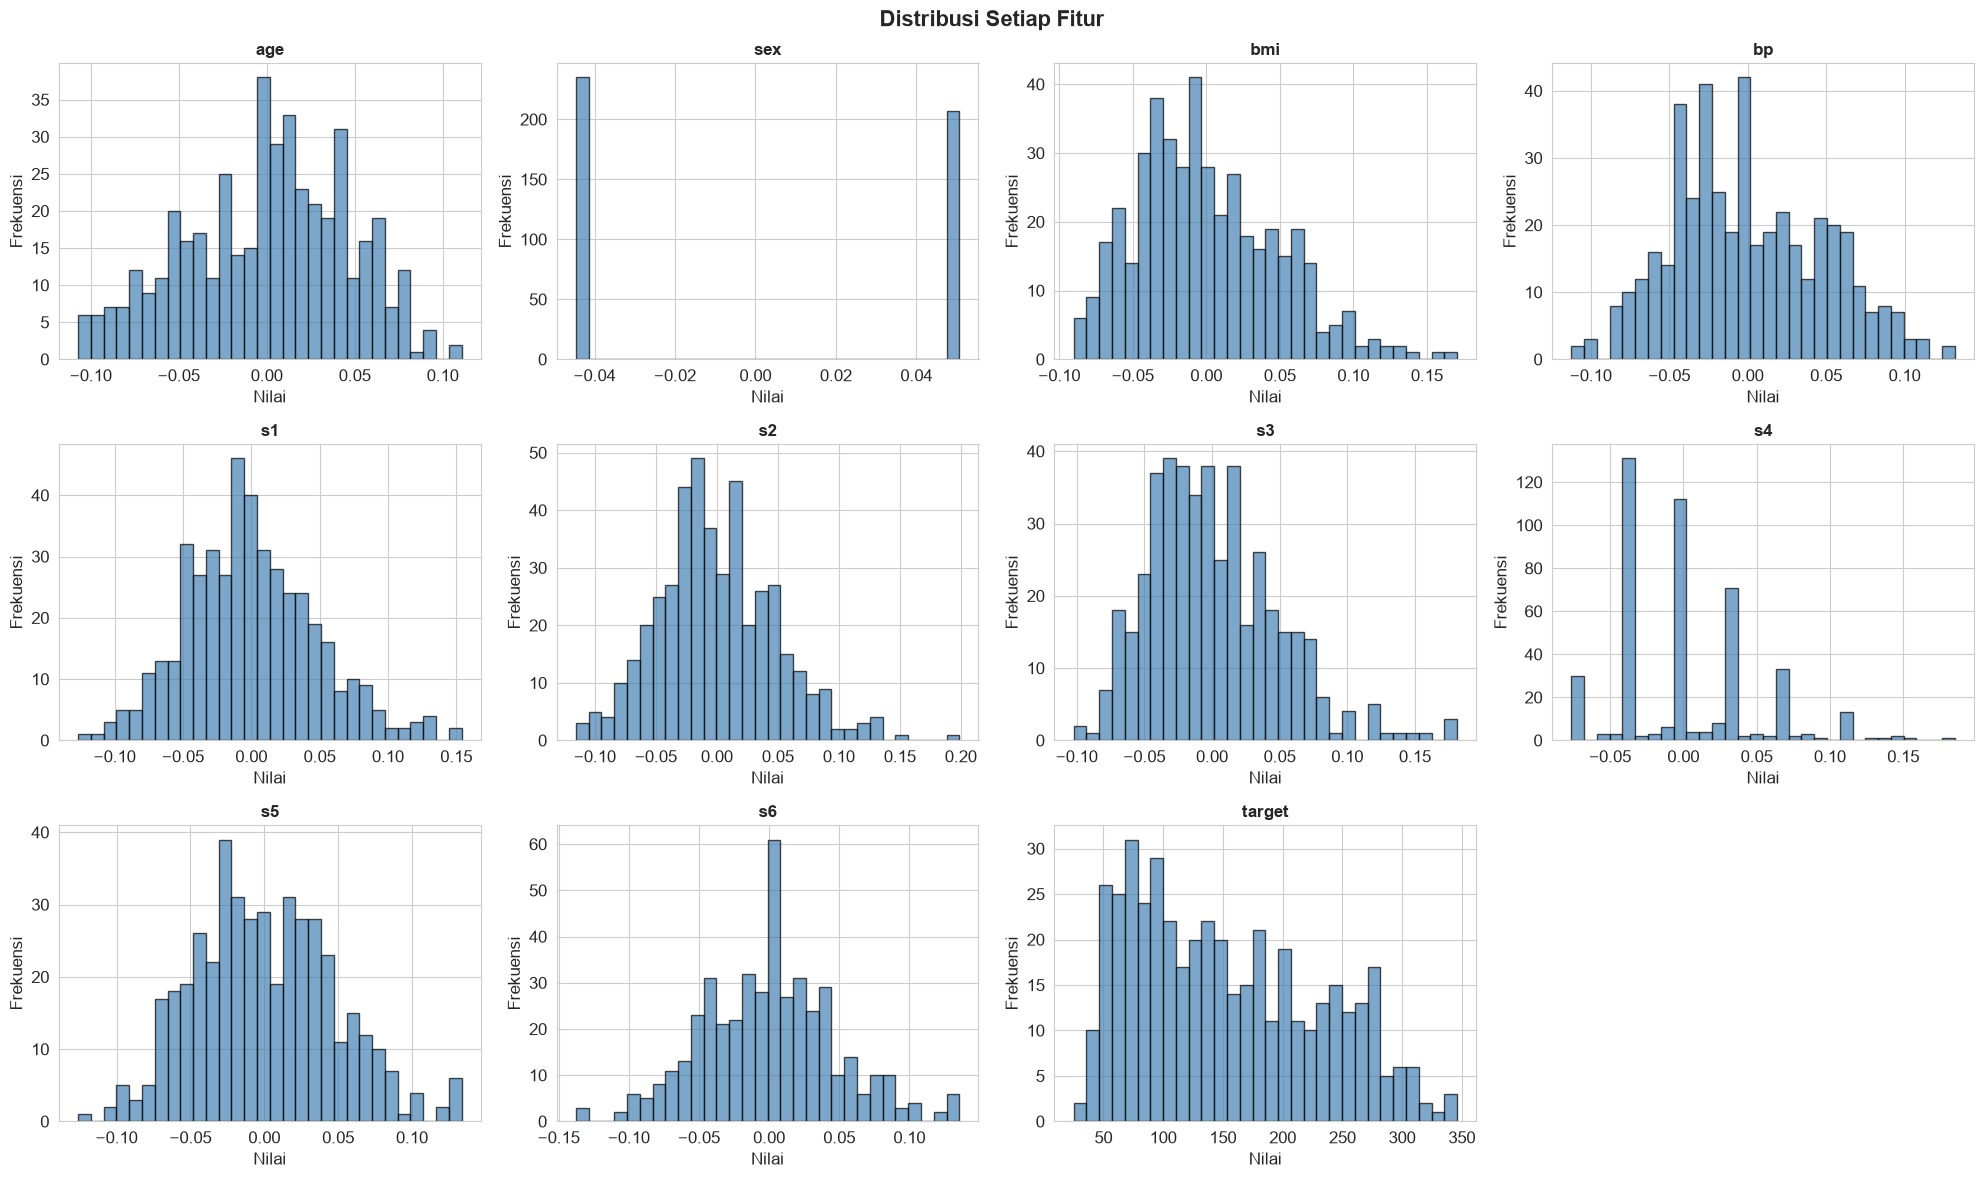

In [10]:
# Visualisasi distribusi setiap fitur menggunakan histogram
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
fig.suptitle('Distribusi Setiap Fitur', fontsize=16, fontweight='bold')

columns = df.columns.tolist()
for i, col in enumerate(columns):
    row = i // 4
    col_idx = i % 4
    ax = axes[row, col_idx]
    ax.hist(df[col], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel('Nilai')
    ax.set_ylabel('Frekuensi')

# Menghapus subplot kosong
if len(columns) < 12:
    axes[2, 3].set_visible(False)

plt.tight_layout()
plt.show()

### 4.4 Korelasi Antar Fitur

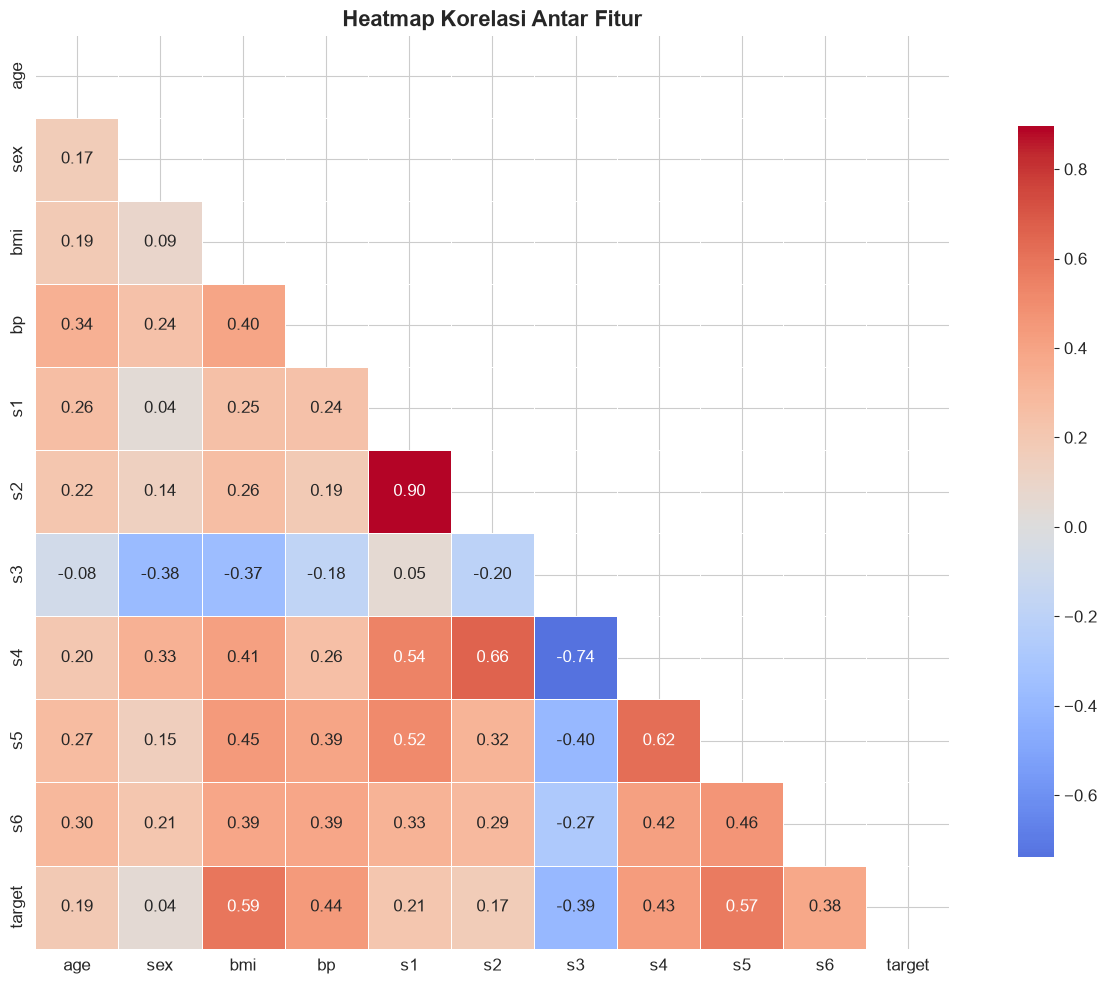

In [11]:
# Heatmap korelasi antar fitur
plt.figure(figsize=(14, 10))
correlation_matrix = df.corr()

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('Heatmap Korelasi Antar Fitur', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

=== Korelasi Fitur terhadap Target ===
bmi    0.586450
s5     0.565883
bp     0.441482
s4     0.430453
s6     0.382483
s1     0.212022
age    0.187889
s2     0.174054
sex    0.043062
s3    -0.394789
Name: target, dtype: float64


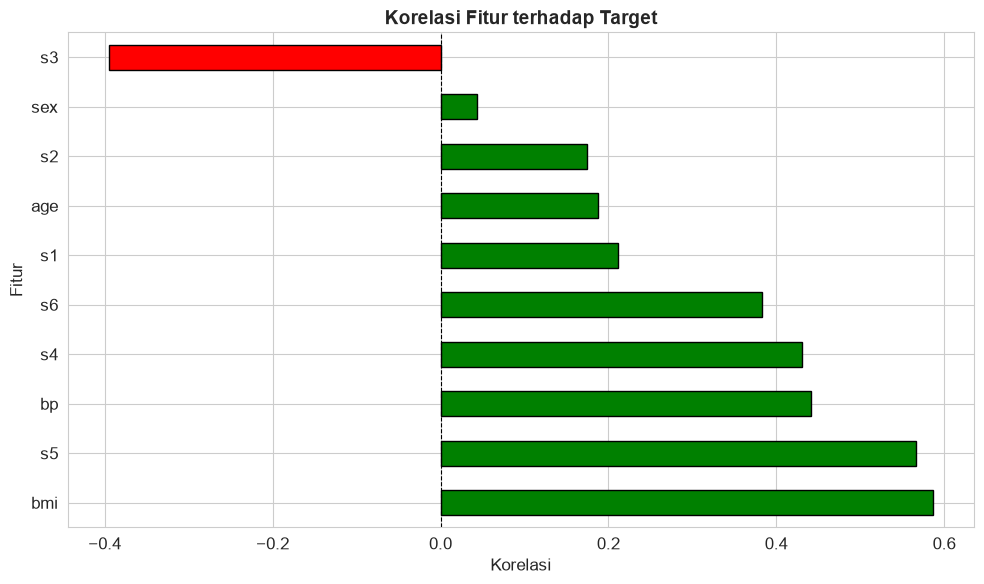

In [12]:
# Korelasi fitur terhadap target
print('=== Korelasi Fitur terhadap Target ===')
target_corr = df.corr()['target'].drop('target').sort_values(ascending=False)
print(target_corr)

# Visualisasi korelasi terhadap target
plt.figure(figsize=(10, 6))
colors = ['green' if x > 0 else 'red' for x in target_corr.values]
target_corr.plot(kind='barh', color=colors, edgecolor='black')
plt.title('Korelasi Fitur terhadap Target', fontsize=14, fontweight='bold')
plt.xlabel('Korelasi')
plt.ylabel('Fitur')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

### 4.5 Distribusi Target Variable

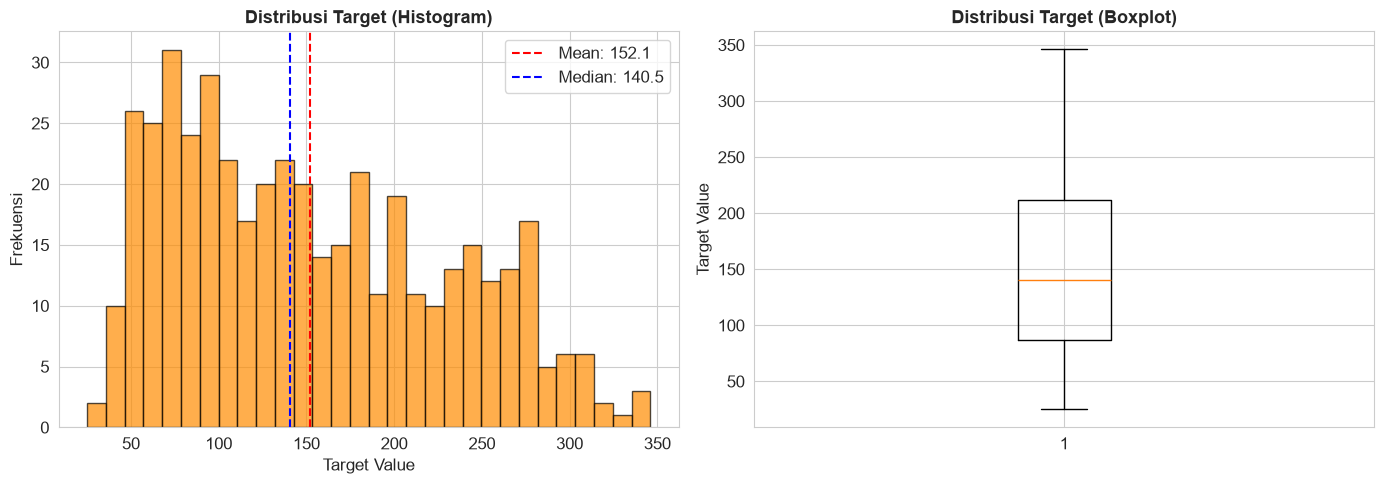

Mean Target: 152.13
Median Target: 140.50
Std Target: 77.09
Min Target: 25.00
Max Target: 346.00


In [13]:
# Distribusi target variable
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['target'], bins=30, color='darkorange', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribusi Target (Histogram)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Target Value')
axes[0].set_ylabel('Frekuensi')
axes[0].axvline(df['target'].mean(), color='red', linestyle='--', label=f'Mean: {df["target"].mean():.1f}')
axes[0].axvline(df['target'].median(), color='blue', linestyle='--', label=f'Median: {df["target"].median():.1f}')
axes[0].legend()

# Boxplot
axes[1].boxplot(df['target'], vert=True)
axes[1].set_title('Distribusi Target (Boxplot)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Target Value')

plt.tight_layout()
plt.show()

print(f'Mean Target: {df["target"].mean():.2f}')
print(f'Median Target: {df["target"].median():.2f}')
print(f'Std Target: {df["target"].std():.2f}')
print(f'Min Target: {df["target"].min():.2f}')
print(f'Max Target: {df["target"].max():.2f}')

### 4.6 Deteksi Outlier dengan Boxplot

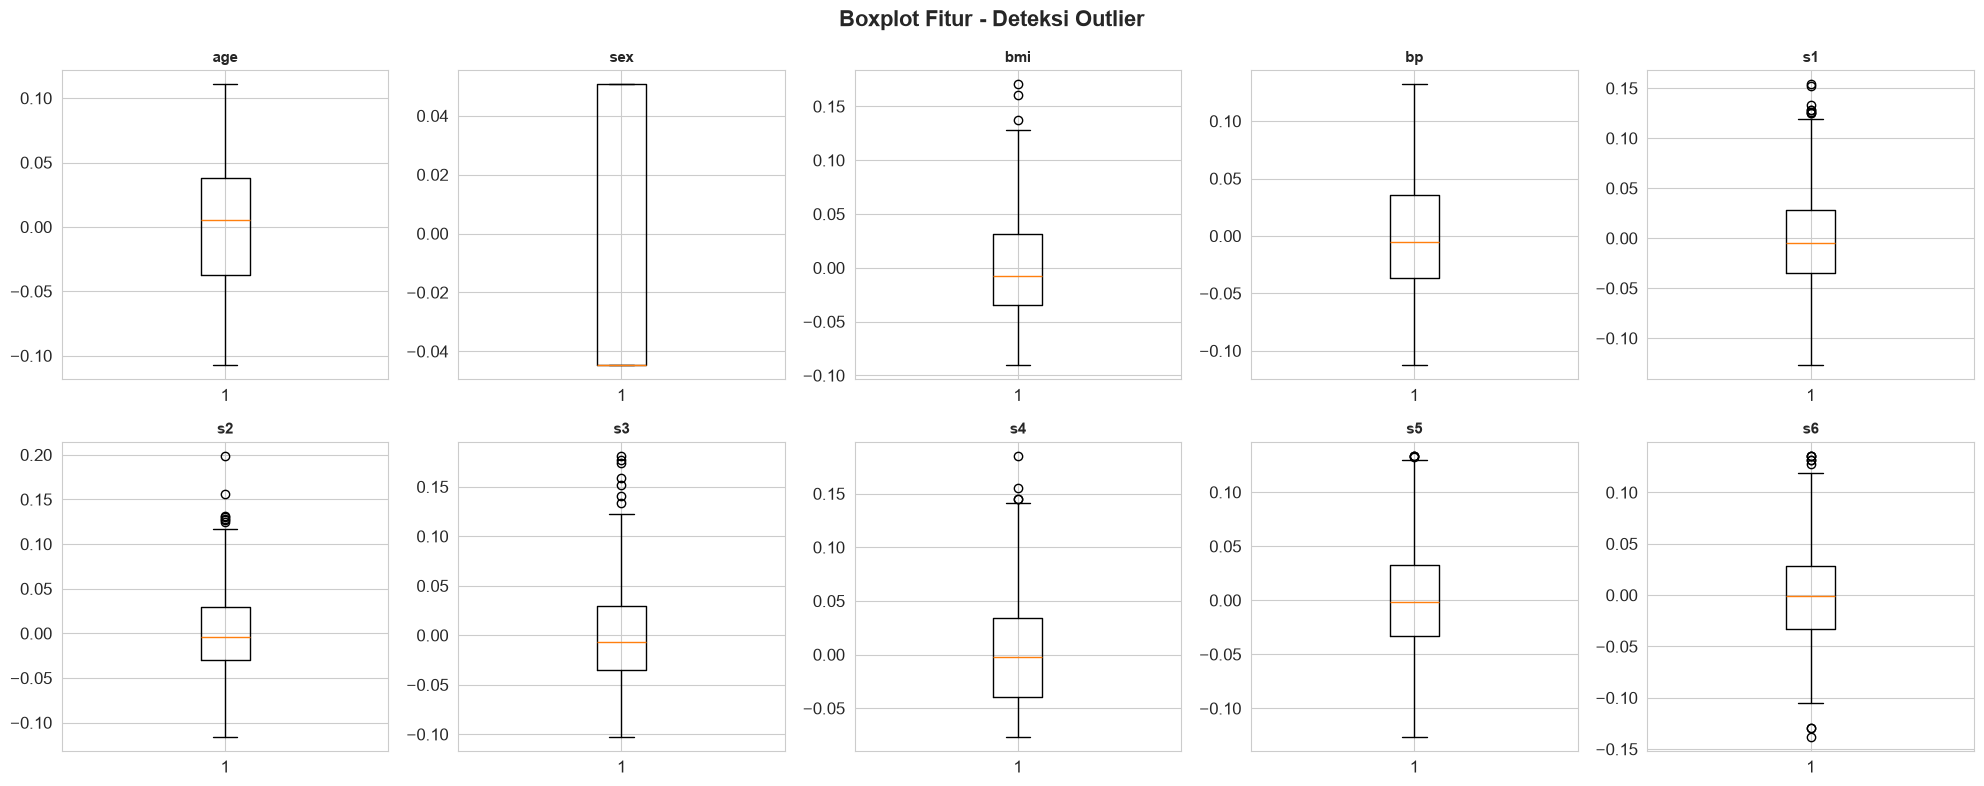

In [14]:
# Boxplot untuk setiap fitur (deteksi outlier)
features = df.columns.drop('target').tolist()

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Boxplot Fitur - Deteksi Outlier', fontsize=16, fontweight='bold')

for i, col in enumerate(features):
    row = i // 5
    col_idx = i % 5
    ax = axes[row, col_idx]
    ax.boxplot(df[col])
    ax.set_title(col, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [15]:
# Menghitung jumlah outlier per fitur menggunakan IQR method
print('=== Jumlah Outlier per Fitur (IQR Method) ===')
outlier_summary = []

for col in features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_summary.append({
        'Fitur': col,
        'Q1': round(Q1, 4),
        'Q3': round(Q3, 4),
        'IQR': round(IQR, 4),
        'Lower Bound': round(lower_bound, 4),
        'Upper Bound': round(upper_bound, 4),
        'Jumlah Outlier': len(outliers),
        'Persentase (%)': round((len(outliers) / len(df)) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df

=== Jumlah Outlier per Fitur (IQR Method) ===


,Fitur,Q1,Q3,IQR,Lower Bound,Upper Bound,Jumlah Outlier,Persentase (%)
0,age,-0.0373,0.0381,0.0754,-0.1504,0.1511,0,0.00
1,sex,-0.0446,0.0507,0.0953,-0.1876,0.1937,0,0.00
2,bmi,-0.0342,0.0312,0.0655,-0.1324,0.1295,3,0.68
3,bp,-0.0367,0.0356,0.0723,-0.1451,0.1441,0,0.00
4,s1,-0.0342,0.0284,0.0626,-0.1282,0.1223,8,1.81
5,s2,-0.0304,0.0298,0.0602,-0.1207,0.1201,7,1.58
6,s3,-0.0351,0.0293,0.0644,-0.1318,0.1260,7,1.58
7,s4,-0.0395,0.0343,0.0738,-0.1502,0.1450,4,0.90
8,s5,-0.0332,0.0324,0.0657,-0.1318,0.1309,4,0.90
9,s6,-0.0332,0.0279,0.0611,-0.1248,0.1196,9,2.04


---
## 5. Data Preprocessing

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:

1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

### 5.1 Menghapus atau Menangani Data Kosong (Missing Values)

In [16]:
# Cek missing values
print('=== Pengecekan Missing Values ===')
print(f'Total missing values: {df.isnull().sum().sum()}')
print()

# Jika ada missing values, handle dengan median (untuk data numerik)
if df.isnull().sum().sum() > 0:
    print('Ditemukan missing values! Melakukan imputasi dengan median...')
    for col in df.columns:
        if df[col].isnull().sum() > 0:
            median_val = df[col].median()
            df[col].fillna(median_val, inplace=True)
            print(f'  - Kolom "{col}": diisi dengan median = {median_val:.4f}')
    print(f'\nSetelah imputasi, total missing values: {df.isnull().sum().sum()}')
else:
    print('Tidak ada missing values pada dataset. Data sudah lengkap!')

=== Pengecekan Missing Values ===
Total missing values: 0

Tidak ada missing values pada dataset. Data sudah lengkap!


### 5.2 Menghapus Data Duplikat

In [17]:
# Cek dan hapus data duplikat
print('=== Pengecekan Data Duplikat ===')
duplicates_before = df.duplicated().sum()
print(f'Jumlah data duplikat: {duplicates_before}')

if duplicates_before > 0:
    print(f'Ukuran dataset sebelum hapus duplikat: {df.shape[0]}')
    df = df.drop_duplicates()
    print(f'Ukuran dataset setelah hapus duplikat: {df.shape[0]}')
    print(f'Data duplikat berhasil dihapus! ({duplicates_before} baris dihapus)')
else:
    print('Tidak ada data duplikat pada dataset.')

=== Pengecekan Data Duplikat ===
Jumlah data duplikat: 0
Tidak ada data duplikat pada dataset.


### 5.3 Deteksi dan Penanganan Outlier

In [18]:
# Deteksi dan penanganan outlier menggunakan IQR method
# Metode: Capping (mengganti outlier dengan batas IQR)
print('=== Penanganan Outlier (IQR Capping) ===')

features = df.columns.drop('target').tolist()
df_clean = df.copy()

for col in features:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outlier_count = ((df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)).sum()
    
    if outlier_count > 0:
        df_clean[col] = df_clean[col].clip(lower=lower_bound, upper=upper_bound)
        print(f'  - Fitur "{col}": {outlier_count} outlier di-capping ke [{lower_bound:.4f}, {upper_bound:.4f}]')

print(f'\nUkuran dataset setelah penanganan outlier: {df_clean.shape}')

=== Penanganan Outlier (IQR Capping) ===
  - Fitur "bmi": 3 outlier di-capping ke [-0.1324, 0.1295]
  - Fitur "s1": 8 outlier di-capping ke [-0.1282, 0.1223]
  - Fitur "s2": 7 outlier di-capping ke [-0.1207, 0.1201]
  - Fitur "s3": 7 outlier di-capping ke [-0.1318, 0.1260]
  - Fitur "s4": 4 outlier di-capping ke [-0.1502, 0.1450]
  - Fitur "s5": 4 outlier di-capping ke [-0.1318, 0.1309]
  - Fitur "s6": 9 outlier di-capping ke [-0.1248, 0.1196]

Ukuran dataset setelah penanganan outlier: (442, 11)


### 5.4 Normalisasi atau Standarisasi Fitur

In [19]:
# Memisahkan fitur dan target
X = df_clean.drop('target', axis=1)
y = df_clean['target']

print(f'Shape fitur (X): {X.shape}')
print(f'Shape target (y): {y.shape}')

# Split data menjadi training dan testing set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'\nUkuran Training Set: {X_train.shape[0]} sampel')
print(f'Ukuran Testing Set: {X_test.shape[0]} sampel')

Shape fitur (X): (442, 10)
Shape target (y): (442,)

Ukuran Training Set: 353 sampel
Ukuran Testing Set: 89 sampel


In [20]:
# Standarisasi fitur menggunakan StandardScaler
scaler = StandardScaler()

# Fit pada training data, transform pada training dan testing data
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print('=== Statistik Fitur Setelah Standarisasi (Training Set) ===')
print(f'Mean (mendekati 0):\n{X_train_scaled.mean().round(6)}')
print(f'\nStd (mendekati 1):\n{X_train_scaled.std().round(6)}')

=== Statistik Fitur Setelah Standarisasi (Training Set) ===
Mean (mendekati 0):
age    0.0
sex    0.0
bmi    0.0
bp     0.0
s1    -0.0
s2     0.0
s3     0.0
s4    -0.0
s5    -0.0
s6    -0.0
dtype: float64

Std (mendekati 1):
age    1.001419
sex    1.001419
bmi    1.001419
bp     1.001419
s1     1.001419
s2     1.001419
s3     1.001419
s4     1.001419
s5     1.001419
s6     1.001419
dtype: float64


### 5.5 Menyimpan Hasil Preprocessing

In [21]:
# Menggabungkan kembali fitur dan target untuk disimpan
# Menggunakan data yang sudah di-clean (outlier handled) tapi belum di-scale
# karena scaling akan dilakukan saat modelling
df_preprocessed = df_clean.copy()

# Simpan dataset yang sudah dipreprocess
output_path = 'diabetes_preprocessing.csv'
df_preprocessed.to_csv(output_path, index=False)

print(f'Dataset hasil preprocessing berhasil disimpan ke: {output_path}')
print(f'Dimensi dataset akhir: {df_preprocessed.shape}')
print(f'\n=== 5 Baris Pertama Dataset Hasil Preprocessing ===')
df_preprocessed.head()

Dataset hasil preprocessing berhasil disimpan ke: diabetes_preprocessing.csv
Dimensi dataset akhir: (442, 11)

=== 5 Baris Pertama Dataset Hasil Preprocessing ===


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [22]:
# Ringkasan Preprocessing
print('=' * 60)
print('RINGKASAN DATA PREPROCESSING')
print('=' * 60)
print(f'Dataset Awal          : 442 baris x 11 kolom')
print(f'Dataset Akhir         : {df_preprocessed.shape[0]} baris x {df_preprocessed.shape[1]} kolom')
print(f'Missing Values        : 0 (tidak ada)')
print(f'Duplikat Dihapus      : 0 (tidak ada)')
print(f'Outlier Handling      : IQR Capping')
print(f'Standarisasi          : StandardScaler')
print(f'Train/Test Split      : 80/20 (random_state=42)')
print(f'Training Samples      : {X_train.shape[0]}')
print(f'Testing Samples       : {X_test.shape[0]}')
print(f'Output File           : {output_path}')
print('=' * 60)

RINGKASAN DATA PREPROCESSING
Dataset Awal          : 442 baris x 11 kolom
Dataset Akhir         : 442 baris x 11 kolom
Missing Values        : 0 (tidak ada)
Duplikat Dihapus      : 0 (tidak ada)
Outlier Handling      : IQR Capping
Standarisasi          : StandardScaler
Train/Test Split      : 80/20 (random_state=42)
Training Samples      : 353
Testing Samples       : 89
Output File           : diabetes_preprocessing.csv
